In [1]:
import pandas as pd
import numpy as np

# 读取数据
df = pd.read_csv("regional_economy_420.csv")

# 仅保留需要的变量
data = df[['Region', 'X4', 'X5', 'X6']].copy()

In [2]:
# ===== 熵权法 =====

# 1. 极差标准化（正向指标）
norm = (data[['X4', 'X5', 'X6']] - data[['X4', 'X5', 'X6']].min()) / \
       (data[['X4', 'X5', 'X6']].max() - data[['X4', 'X5', 'X6']].min())

# 防止 log(0)
norm = norm.replace(0, 1e-12)

# 2. 计算比重 pij
p = norm / norm.sum(axis=0)

# 3. 计算熵值
n = len(norm)
k = 1 / np.log(n)
entropy = -k * (p * np.log(p)).sum(axis=0)

# 4. 信息效用值
d = 1 - entropy

# 5. 熵权
weights_entropy = d / d.sum()

weights_entropy

X4    0.387711
X5    0.320278
X6    0.292011
dtype: float64

In [4]:
# ===== TOPSIS =====

# 1. 向量标准化
Z = norm / np.sqrt((norm**2).sum())

# 2. 构造加权标准化矩阵
V = Z * weights_entropy.values

# 3. 正理想解 & 负理想解
V_plus = V.max()
V_minus = V.min()

# 4. 计算距离
D_plus = np.sqrt(((V - V_plus)**2).sum(axis=1))
D_minus = np.sqrt(((V - V_minus)**2).sum(axis=1))

# 5. 相对贴近度
data['TOPSIS_score'] = D_minus / (D_plus + D_minus)

# 排序
topsis_rank = data.sort_values('TOPSIS_score', ascending=False)
topsis_rank.head()


,Region,X4,X5,X6,TOPSIS_score
19,省份04,87.90,4.30,81.0,0.910195
11,省份24,85.10,4.00,84.0,0.876429
15,省份17,91.62,3.04,72.0,0.780459
12,省份13,62.62,4.10,87.0,0.660310
22,省份26,86.58,2.75,40.0,0.631468


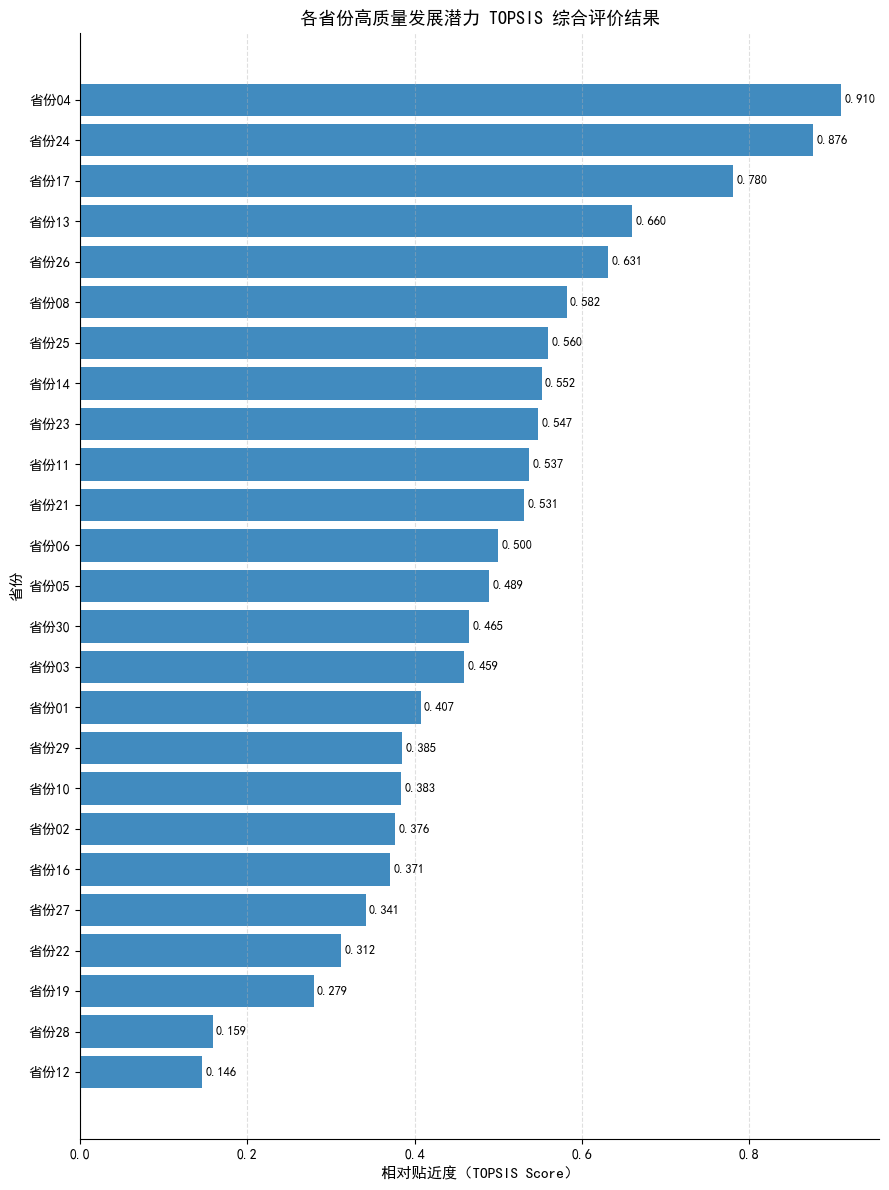

In [10]:
import matplotlib.pyplot as plt

# 中文字体设置
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plot_data = topsis_rank.copy()

plt.figure(figsize=(9, 12))

# 横向条形图（适度透明）
bars = plt.barh(
    plot_data['Region'],
    plot_data['TOPSIS_score'],
    alpha=0.85
)

# 排名第一在最上方
plt.gca().invert_yaxis()

# 添加数值标签
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.004,                         # 右侧留白
        bar.get_y() + bar.get_height() / 2,
        f'{width:.3f}',
        va='center',
        fontsize=9,
        color='black'
    )

# 坐标轴与标题
plt.xlabel('相对贴近度（TOPSIS Score）', fontsize=11)
plt.ylabel('省份', fontsize=11)
plt.title('各省份高质量发展潜力 TOPSIS 综合评价结果', fontsize=13)

# 网格线（只保留横向参考，弱化视觉干扰）
plt.grid(axis='x', linestyle='--', alpha=0.4)

# 去掉上、右边框（论文常用）
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [8]:
# ===== 等权平均法 =====

data['Mean_score'] = norm.mean(axis=1)

mean_rank = data.sort_values('Mean_score', ascending=False)
mean_rank.head(10)


,Region,X4,X5,X6,TOPSIS_score,Mean_score
19,省份04,87.90,4.30,81.0,0.910195,0.923701
11,省份24,85.10,4.00,84.0,0.876429,0.888779
15,省份17,91.62,3.04,72.0,0.780459,0.804281
12,省份13,62.62,4.10,87.0,0.660310,0.751820
1,省份08,50.84,4.12,91.0,0.581833,0.686271
22,省份26,86.58,2.75,40.0,0.631468,0.623509
20,省份21,55.96,3.14,74.0,0.531287,0.571493
5,省份25,80.52,2.11,49.0,0.559769,0.558140
13,省份23,88.46,1.52,46.0,0.547258,0.550073
16,省份14,82.77,2.01,44.0,0.551851,0.546269


In [12]:
top3_topsis = topsis_rank[['Region', 'TOPSIS_score']].head(5)
top3_mean = mean_rank[['Region', 'Mean_score']].head(5)

print("TOPSIS（熵权）前5名：")
print(top3_topsis)

print("\n等权平均法前5名：")
print(top3_mean)

TOPSIS（熵权）前5名：
   Region  TOPSIS_score
19   省份04      0.910195
11   省份24      0.876429
15   省份17      0.780459
12   省份13      0.660310
22   省份26      0.631468

等权平均法前5名：
   Region  Mean_score
19   省份04    0.923701
11   省份24    0.888779
15   省份17    0.804281
12   省份13    0.751820
1    省份08    0.686271
